# <font color='orange'>TME ROBOTIQUE ET APPRENTISSAGE</font>
# <font color='orange'>1. Stratégies d'Evolution</font>

# <font color="green">Version ETUDIANT·ES 2025-2026</font>

*mise à jour: 24/2/2026*

Ce notebook doit être exécuté dans [Google Colab](colab.research.google.com/) ou dans Jupyter.

A la fin du TME, vous devez déposer votre travail sur Moodle:
* déposer votre notebook, avec le nom de fichier *obligatoirement* au format suivant: **RA_NOM1_NOM2.ipynb**
* toutes les cellules doivent être exécutées avec les graphes visibles
* un **bref** commentaire lorsque c'est demandé. Pour toutes les questions, une à deux phrases suffisent

*Le sujet est à faire en binome.*

# COMPLETEZ LES CHAMPS CI-DESSOUS AVEC NOM/PRENOM/CARTE_ETU:

* Étudiant 1: **_ZHANG_ _Yuxiang_ _21202829_**
* Étudiant 2: **_Alsafadi_ _Kenan_ _21502362_**



---
---
---

# <font color='orange'>PREAMBULE: initialisation</font>

# Importation des librairies nécessaires et fonctions utiles

Il n'est pas nécessaire de regarder le code de ces cellules, elles sont utiles pour les fonctions utilisées dans la partie A.

Remarque: *Sauf en cas de redémarrage du noyau, il suffit d'exécuter ces cellules une seule fois.*

In [1]:
from datetime import datetime
from datetime import date
#import importlib # une seule fois
import sys
import random
import matplotlib.pyplot as plt
#from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import
import numpy as np
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from scipy.optimize import minimize

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")


 2026-02-26 14:07:50 GMT
OK.


In [2]:
#!pip install numpy scipy matplotlib pandas sympy nose
!pip install deap
!pip install cma
#!pip install --user pygame

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.5 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for deap: filename=deap-1.4.3-cp39-cp39-macosx_10_9_universal2.whl size=111228 sha256=73d3cc35056f1368b7cff30ead2ed88ca8f1efaeda2f017f8913b7c5f3dfdac7
  Stored in directory: /Users/yuxiangzhang/Library/Caches/pip/wheels/a4/3b/f8/c725d3e0de9af9e834ec4fa7db185b5cf0f77f17019a483daa
Successfully built deap

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip ins

In [3]:
# plot

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import
import numpy as np
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import random
from scipy.optimize import minimize


def plot_results(my_func, my_points, min_x=-30, max_x=30, min_y=-30, max_y=30, nbx=100, nby=100, title="Title"):
    """Plots a 2D function with a heatmap and the points given as argument are plotted on top of it

    Plots a 2D function with a heatmap and the points given as argument are plotted on top of it:
    :param my_func: the function to plot on the background
    :param my_points: the points to plot
    :param min_x: min value of x
    :param max_x: max value of x
    :param min_y: min value of y
    :param max_y: max value of y
    :param nbx: number of my_func samples on the X-axis
    :param nby: number of my_func samples on the Y-axis
    :param title: title of the figure
    """
    X = np.linspace(min_x, max_x, num=nbx)
    Y = np.linspace(min_y, max_y, num=nby)
    Z=np.zeros((nbx,nby),dtype=np.double)
    for i in range(nbx):
        for j in range(nby):
            Z[i][j]=my_func(np.array([X[i],Y[j]]))
    fig,ax=plt.subplots(figsize=(5,5))
    ax.set_xlim(min_x,max_x)
    ax.set_ylim(min_y,max_y)
    ax.imshow(Z, cmap='hot', interpolation='nearest',extent=(min_x,max_x,min_y,max_y),origin='lower')

    #print("Points: "+str(my_points))
    x=[]
    y=[]
    for p in my_points:
        x.append(p[0])
        y.append(p[1])

    ax.plot(x,y,".")
    ax.set_title(title)
    plt.show()

def plot_violin(res):
    """ Makes a violin plot of the results provided in the argument

    Makes a violin plot of the results provided in the argument.
    :param res: dictionary of the results to plot. The key is the name and the data is a vector of performance values.
    """
    fig,ax=plt.subplots(figsize=(5,5))
    data=[]
    labels=[]
    for k in res.keys():
        data.append(res[k])
        labels.append(k)
    ax.violinplot(data,
                   showmeans=False,
                   showmedians=True)
    ax.set_title('Violin plot')
    # adding horizontal grid lines
    ax.yaxis.grid(True)
    ax.set_xticks([y + 1 for y in range(len(data))])
    ax.set_xlabel('Optimization methods')
    ax.set_ylabel('Best value found')

    # add x-tick labels
    plt.setp(ax, xticks=[y + 1 for y in range(len(data))],
        xticklabels=labels)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    plt.show()

# Generate points in 2D space for visualizing the function
def draw_function(func,title='Function',x1_min=-12,x1_max=12,x2_min=-12,x2_max=12,resolution=100):
    """ Makes a graph visualising the shape of the function provided as argument
    Only the first 2 dimensions are plotted
    :param: the function name, optional argument are title and ranges.

    """
    x1 = np.linspace(x1_min, x1_max, resolution)
    x2 = np.linspace(x2_min, x2_max, resolution)
    X1, X2 = np.meshgrid(x1, x2)
    points = np.vstack([X1.ravel(), X2.ravel()]).T
    #Y = func(points) # only works if function handle N points at once. Otherwise use block below
    ##
    Y_results = []
    for point in points:
        result = func(point)  # Apply func to each point individually
        Y_results.append(result)
    Y = np.array(Y_results).reshape(X1.shape)
    ##
    Y = Y.reshape(X1.shape)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X1, X2, Y, cmap='Oranges') #magma_r, hot_r, coolwarm_r

    ax.set_title(title)
    ax.set_xlabel('x_1')
    ax.set_ylabel('x_2')
    #ax.set_zlabel('f(X)')

    plt.show()

# plot data from an array. Used to plot value throughout course of optimization (ex.: best or best-ever through evaluations)
def plot_data(data, title=None, x_label=None, y_label=None, interval=1, y_min=None, y_max=None):
    x_values = range(0, len(data), interval)
    y_values = data[::interval]
    x_ticks = range(len(data))[::interval]
    plt.figure(figsize=(5, 3))
    plt.plot(x_values, y_values, marker='o', linestyle='-', color='darkblue')
    if title is not None:
      plt.title(title)
    if x_label is not None:
      plt.xlabel(x_label)
    if y_label is not None:
      plt.ylabel(y_label)
    plt.grid(True)
    plt.xticks(x_ticks)
    plt.xticks(rotation=90)
    if y_min is not None and y_max is not None:
        plt.ylim(y_min, y_max)
    plt.show()

# example of use:
#data = [0.1032688567595802, 0.05606506259991306, 0.11534983662403742, 0.16138874628796385, 0.040744926078464805, 0.26695076981109866, 0.06779240396028519, 0.03673999782379245, 0.62403741153498362]
#plot_data(data,title="example of use",y_min=0,y_max=1.0,interval=2)

# =-=-=-=-=

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")




 2026-02-26 14:07:59 GMT
OK.


---
---
---

# <font color='orange'>PARTIE A: RECHERCHE NAIVE ET FONCTIONS CARACTERISTIQUES</font>

---

# Exercice A.1 : fonctions objectifs classiques

*Il n'est pas nécessaire de regarder le contenu de la cellule suivant pour répondre aux questions ci-dessous. Le résultat de son exécution suffit.*

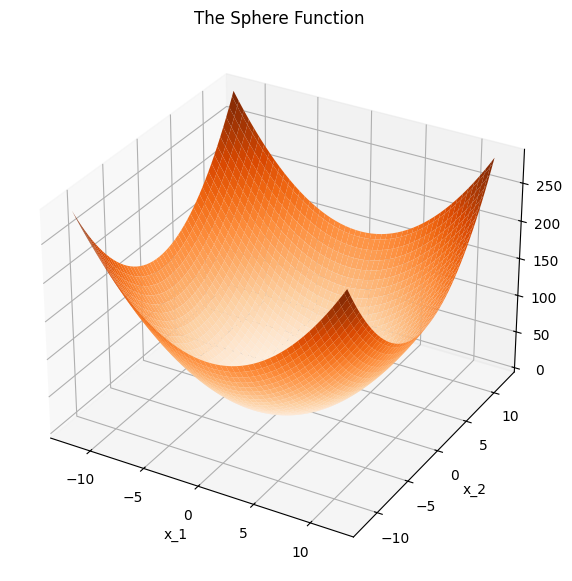

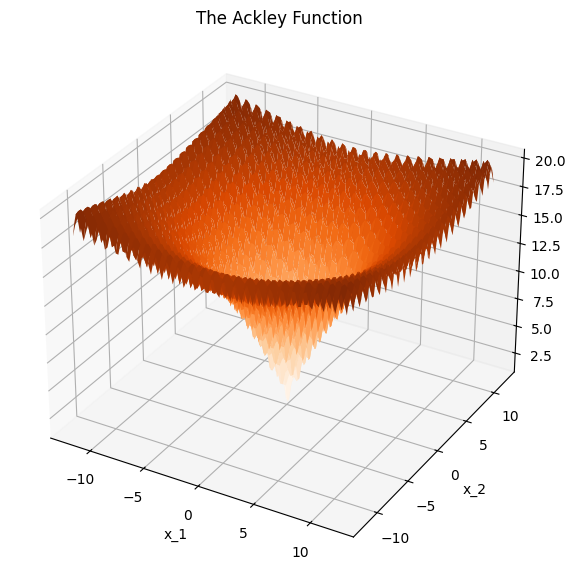

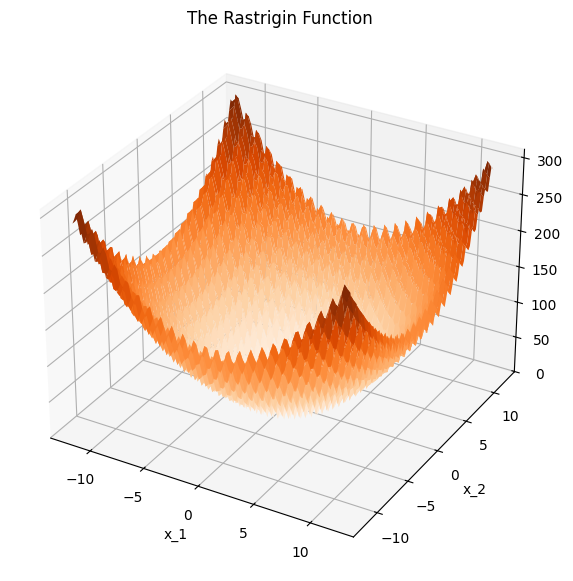

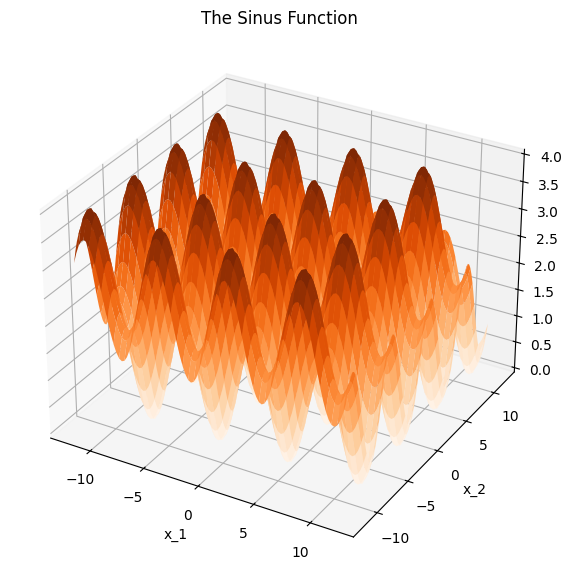

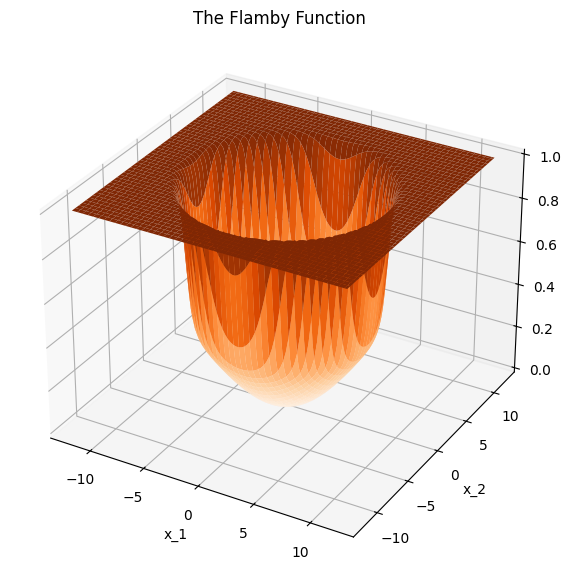



 2026-02-26 14:08:00 GMT
OK.


In [4]:
# myEvalFn
# requires: CMA

import sys
from deap import benchmarks
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def sphere(x):
    return benchmarks.sphere(x)[0]

draw_function(sphere,"The Sphere Function")
print ()

def ackley(x):
    return benchmarks.ackley(x)[0]

draw_function(ackley,"The Ackley Function")
print ()

def rastrigin(x):
    return benchmarks.rastrigin(x)[0]

draw_function(rastrigin,"The Rastrigin Function")
print ()

def multimodal_sine(x):
    """
    Compute the multimodal sine function value for a multi-dimensional input vector x.

    :param x: A numpy array representing the input vector of size N.
    :return: The computed value of the multimodal sine function for each element of x, summed.
    """
    # Apply the sine function to each element of x and sum the results
    result = np.sum(np.sin(x) + 1)
    return result

draw_function(multimodal_sine,"The Sinus Function")
print ()

def sigmoid(x, k=1): # used for Flamby function
    return 1 / (1 + np.exp(-k * x))

# flamby function is a smooth_gaussian which transition from gaussian to flat thanks to a sigmoid
# it works for both single and multiple points
# Usage: flamby(x) => fitness (used for minimisation)
# optional parameters:
#   a for gaussian height
#   c for gaussian width
#   k for sharpness of transition to flat outside the central region
def flamby(x, a=1, c=8, k=5):
    # Determine if x is a single point or an array of points
    if x.ndim == 1:
        dist = np.sqrt(np.sum(x**2))
    else:
        dist = np.sqrt(np.sum(x**2, axis=1))
    gaussian_part = a * np.exp(-(dist)**2 / (2 * c**2))
    transition = sigmoid(k * (c - dist)) * sigmoid(k * (c + dist))
    return 1.0 - gaussian_part * transition

draw_function(flamby,'The Flamby Function')
print ()

# Evaluate the Flamby function for a few single points in 3D and 10D space
'''
x_point = np.array([0.0, 0.0, 0.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.0, 0.0, 0.1])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.1, 0.1, 0.1])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.0, 0.0, 2.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([2.0, 2.0, 2.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([8.0, 8.0, 8.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([9.0, 9.0, 9.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
x_point = np.array([5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0])
print(f"The result of the function at point {x_point} is: {flamby(x_point)}")
# remark: increasing the number of dimensions narrow the region with non-flat response.
'''

#### #### ####

print("\n",date.today(), datetime.now().strftime("%H:%M:%S"),"GMT") # timestamp is greenwich time
print("OK.")

# Questions

Exécutez la cellule ci-avant et observez les fonctions affichées.

1. Quelles sont les fonctions multimodales?
Ackley, Rastrigin et Multimodal Sine.

2. Que dire de la fonction Sinus?
Elle est très multimodale avec une infinité de minima.

3. Que dire de la fonction Flamby?
Elle est unimodale (un seul minimum) mais avec un plateau plat.


---

# Exercice A.2 : recherche au hasard

Le code ci-dessous lance une recherche aléatoire sur une fonction objectif passée en paramètre (fonction Flamby par défaut). Etudiez le code puis exécutez le avant de passer à la suite.

Remarque: *la variable dimensions définit (comme son nom l'indique) le nombre de dimensions du problème. La fonction plot_results n'affiche que les deux premières dimensions. Si le nombre de dimensions est supérieur à 2, la position affichée d'un individu peut ne pas rendre compte exactement de sa qualité.*

In [5]:
# NE PAS MODIFIER -- vous pouvez copier ce code et le modifier pour répondre aux questions des exercices suivants

def launch_random(individual, nbeval=10001, display=True, ma_func=flamby, rangeValue=20):
    i=0
    besteverFit = float("inf")
    besteverIt = 0
    besteverSolution = []
    data = []
    while i<nbeval:
        candidateSolution = np.random.uniform(-rangeValue,+rangeValue,len(individual))
        fit = ma_func(candidateSolution)
        if fit <= besteverFit:
            besteverSolution = np.copy(candidateSolution)
            besteverFit = fit
            besteverIt = i
            besteverSolution = np.array([candidateSolution])
        solution = np.array([candidateSolution])
        data.append(besteverFit)
        #if display and i == 0:
        #  plot_results(ma_func,solution, title="Gen %d"%(i), min_x=-15, max_x=15, min_y=-15, max_y=15) # on projette uniquement sur les deux premières dimensions.
        if display and i%(int(nbeval/10))==0:
          print ("it =",i,", current_fit =",fit,", best_fit =",besteverFit)
        i+=1
    if display:
        plot_results(ma_func,besteverSolution, title="Gen %d"%(besteverIt), min_x=-15, max_x=15, min_y=-15, max_y=15) # on projette uniquement sur les deux premières dimensions.
    print ("Best fit",besteverFit,"found at iteration",besteverIt)
    return besteverFit,data


# Recherche naïve sur les fonctions Sphere, Ackley et Rastrigin

Le code ci-dessous fait une recherche au hasard sur trois fonctions classiques en dimension **2** et avec une initialisation **entre -8 et 8** sur chaque dimension.

Exécutez la cellule, observez le résultat.

# Number of dimensions is 2
# Final graph traces the fitness value of the best-ever candidate thoughout optimisation (every 500 evaluations)

=-=-=-=-=
=-=-=-=-= SPHERE
=-=-=-=-=
it = 0 , current_fit = 86.6024741778325 , best_fit = 86.6024741778325
it = 1000 , current_fit = 11.091384145609299 , best_fit = 0.24761174670371275
it = 2000 , current_fit = 2.410088336797077 , best_fit = 0.1604925163766029
it = 3000 , current_fit = 27.014930842480958 , best_fit = 0.018330399968548468
it = 4000 , current_fit = 80.43713719586879 , best_fit = 0.018330399968548468
it = 5000 , current_fit = 37.91999223027957 , best_fit = 0.018330399968548468
it = 6000 , current_fit = 46.594437224760085 , best_fit = 0.018330399968548468
it = 7000 , current_fit = 58.170438294683926 , best_fit = 0.018330399968548468
it = 8000 , current_fit = 38.030825535530575 , best_fit = 0.017795799705217816
it = 9000 , current_fit = 36.881131936838386 , best_fit = 0.017795799705217816
it = 10000 , current_fit = 24.872444704527286 

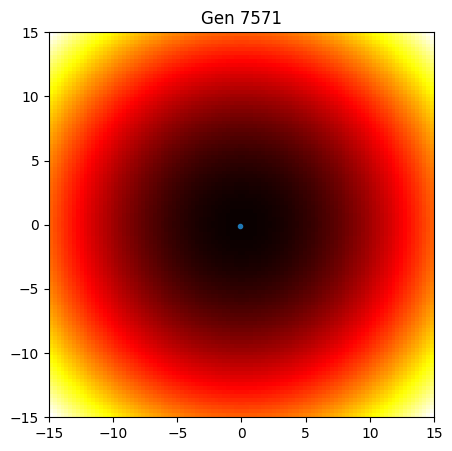

Best fit 0.017795799705217816 found at iteration 7571


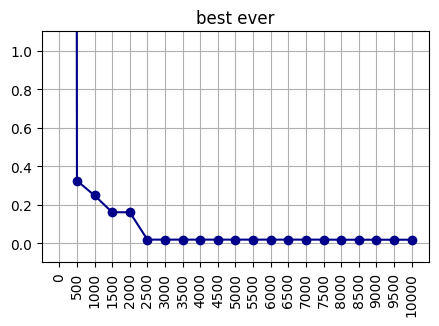


=-=-=-=-=
=-=-=-=-= ACKLEY
=-=-=-=-=
it = 0 , current_fit = 16.17200086294182 , best_fit = 16.17200086294182
it = 1000 , current_fit = 15.073269871447893 , best_fit = 2.140673470444971
it = 2000 , current_fit = 13.928897034286553 , best_fit = 1.816126166639459
it = 3000 , current_fit = 11.361960847238482 , best_fit = 0.22158274222958774
it = 4000 , current_fit = 8.156735772727844 , best_fit = 0.22158274222958774
it = 5000 , current_fit = 12.659381929981455 , best_fit = 0.22158274222958774
it = 6000 , current_fit = 14.890812660255103 , best_fit = 0.22158274222958774
it = 7000 , current_fit = 14.527986371517766 , best_fit = 0.22158274222958774
it = 8000 , current_fit = 10.975894126374454 , best_fit = 0.22158274222958774
it = 9000 , current_fit = 6.665222682479788 , best_fit = 0.22158274222958774
it = 10000 , current_fit = 14.885371617315428 , best_fit = 0.22158274222958774


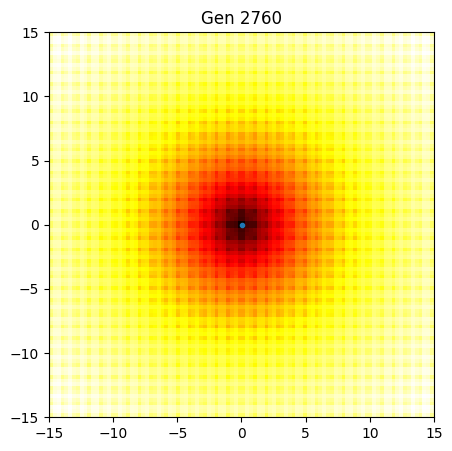

Best fit 0.22158274222958774 found at iteration 2760


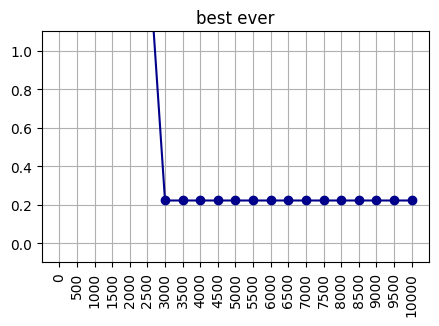


=-=-=-=-=
=-=-=-=-= RASTRIGIN
=-=-=-=-=
it = 0 , current_fit = 55.74409085374427 , best_fit = 55.74409085374427
it = 1000 , current_fit = 48.91871729352401 , best_fit = 2.3299389853212347
it = 2000 , current_fit = 29.337138236184572 , best_fit = 1.4460903252364083
it = 3000 , current_fit = 69.2451388679887 , best_fit = 1.4460903252364083
it = 4000 , current_fit = 85.76667659606946 , best_fit = 1.4460903252364083
it = 5000 , current_fit = 93.69284975291541 , best_fit = 1.4460903252364083
it = 6000 , current_fit = 40.37626975777799 , best_fit = 1.4460903252364083
it = 7000 , current_fit = 88.86635939255632 , best_fit = 1.4460903252364083
it = 8000 , current_fit = 72.2997146838616 , best_fit = 1.4460903252364083
it = 9000 , current_fit = 33.28991011500482 , best_fit = 1.4460903252364083
it = 10000 , current_fit = 49.62134402074361 , best_fit = 1.4460903252364083


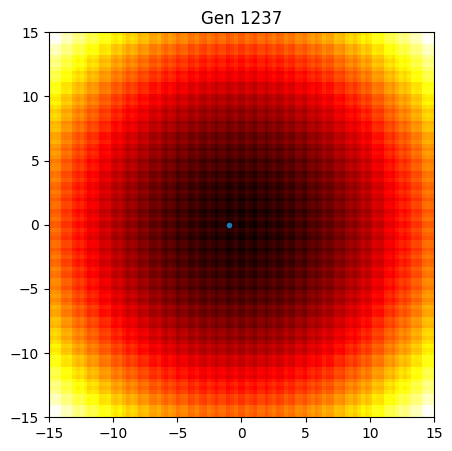

Best fit 1.4460903252364083 found at iteration 1237


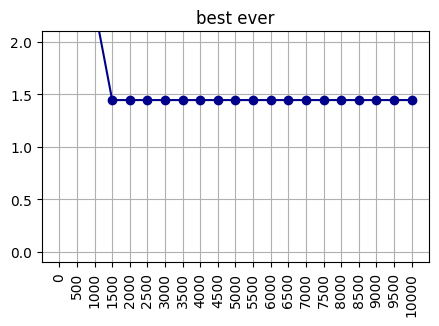

In [6]:
dimensions = 2 # nombre de dimensions de l'espace de recherche
interval=500
print ("# Number of dimensions is",dimensions)
print ("# Final graph traces the fitness value of the best-ever candidate thoughout optimisation (every",interval,"evaluations)")

print ("\n=-=-=-=-=\n=-=-=-=-= SPHERE\n=-=-=-=-=")
res,data = launch_random([0]*dimensions,ma_func=sphere,rangeValue=8)
plot_data(data,title="best ever",interval=interval,y_min=-0.1,y_max=1.1)

print ("\n=-=-=-=-=\n=-=-=-=-= ACKLEY\n=-=-=-=-=")
res,data = launch_random([0]*dimensions,ma_func=ackley,rangeValue=8)
plot_data(data,title="best ever",interval=interval,y_min=-0.1,y_max=1.1)

print ("\n=-=-=-=-=\n=-=-=-=-= RASTRIGIN\n=-=-=-=-=")
res,data = launch_random([0]*dimensions,ma_func=rastrigin,rangeValue=8)
plot_data(data,title="best ever",interval=interval,y_min=-0.1,y_max=2.1)


# Questions

1. Que montre le graphe "Gen XXX" ?
Le graphe "Gen XXX" montre la carte de la fonction (en 2D) avec un point qui indique la meilleure solution trouvée par le hasard, à l'itération XXX.

1. Que montre le graphe "best ever"?
Le graphe "best ever" montre l'évolution de la meilleure valeur trouvée au fil des évaluations (généralement, cette valeur diminue).

# Recherche naïve sur la fonction Sinus

Le code ci-dessous fait une recherche au hasard sur la fonction **Sinus** (multimodale) en dimension **2** et avec une initialisation **entre -8 et 8** sur chaque dimension.

Exécutez la cellule, observez le résultat.

# Number of dimensions is 2
# Final graph traces the fitness value of the best-ever candidate thoughout optimisation (every 500 evaluations)

=-=-=-=-=
=-=-=-=-= SINUS
=-=-=-=-=
it = 0 , current_fit = 1.1338680022113665 , best_fit = 1.1338680022113665
it = 1000 , current_fit = 1.6272366856399234 , best_fit = 0.0003162575138552226
it = 2000 , current_fit = 0.37802834193644297 , best_fit = 3.0594314669118994e-05
it = 3000 , current_fit = 1.1670607381581202 , best_fit = 3.0594314669118994e-05
it = 4000 , current_fit = 1.1065707066651889 , best_fit = 3.0594314669118994e-05
it = 5000 , current_fit = 0.7882725722699666 , best_fit = 3.0594314669118994e-05
it = 6000 , current_fit = 1.241528817757667 , best_fit = 3.0594314669118994e-05
it = 7000 , current_fit = 1.7085933769422317 , best_fit = 3.0594314669118994e-05
it = 8000 , current_fit = 1.6014472417131485 , best_fit = 3.0594314669118994e-05
it = 9000 , current_fit = 0.8617968908760706 , best_fit = 3.0594314669118994e-05
it = 10000 , current

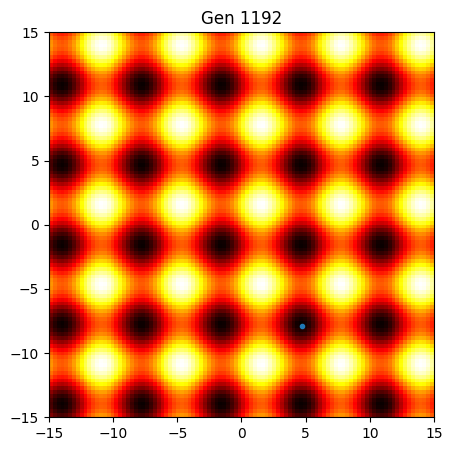

Best fit 3.0594314669118994e-05 found at iteration 1192


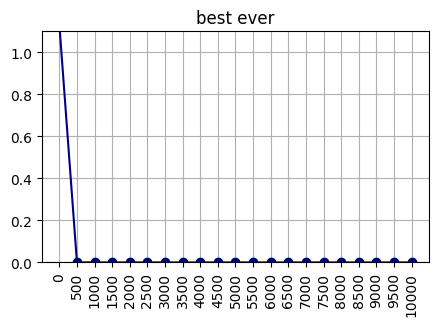

In [12]:
dimensions = 2 # nombre de dimensions de l'espace de recherche
interval=500
print ("# Number of dimensions is",dimensions)
print ("# Final graph traces the fitness value of the best-ever candidate thoughout optimisation (every",interval,"evaluations)")

print ("\n=-=-=-=-=\n=-=-=-=-= SINUS\n=-=-=-=-=")
res,data = launch_random([0]*dimensions,ma_func=multimodal_sine,rangeValue=8)
plot_data(data,title="best ever",interval=interval,y_min=0,y_max=1.1)


# Questions

1. Relancer plusieurs fois la recherche aléatoire sur la fonction Sinus. Qu'observez-vous? Pourquoi?
Le best_fit finit toujours par être très proche de 0.
Car la fonction Sinus a beaucoup de minima globaux (infinis) dans l'espace de recherche. En essayant 10 000 points au hasard, on finit forcément par en trouver un.

# Recherche naïve sur la fonction Flamby

Le code ci-dessous fait une recherche au hasard sur la fonction **Flamby** en dimension **12** et avec une initialisation **entre -8 et 8** sur chaque dimension.

Exécutez la cellule, observez le résultat.


=-=-=-=-=
=-=-=-=-= FLAMBY
=-=-=-=-=
it = 0 , current_fit = 0.9999997030438575 , best_fit = 0.9999997030438575
it = 1000 , current_fit = 0.9999994011659094 , best_fit = 0.2122834043683317
it = 2000 , current_fit = 0.9998227198875798 , best_fit = 0.20228070810941945
it = 3000 , current_fit = 0.9986966784815674 , best_fit = 0.20228070810941945
it = 4000 , current_fit = 0.9999077214935717 , best_fit = 0.20228070810941945
it = 5000 , current_fit = 0.79059161551113 , best_fit = 0.20228070810941945
it = 6000 , current_fit = 0.99999999117594 , best_fit = 0.18536678935159212
it = 7000 , current_fit = 0.9999962378031555 , best_fit = 0.18536678935159212
it = 8000 , current_fit = 0.6027206198517412 , best_fit = 0.18536678935159212
it = 9000 , current_fit = 0.8251717581462243 , best_fit = 0.18536678935159212
it = 10000 , current_fit = 0.9909674913058171 , best_fit = 0.18536678935159212


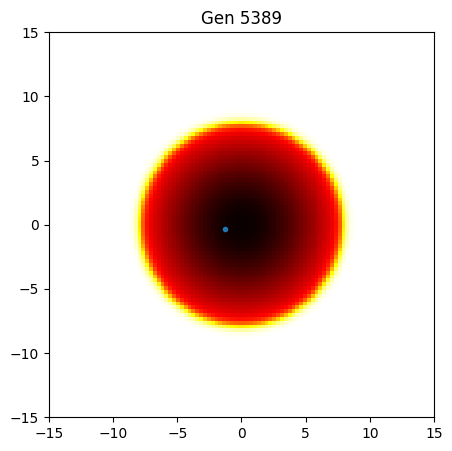

Best fit 0.18536678935159212 found at iteration 5389


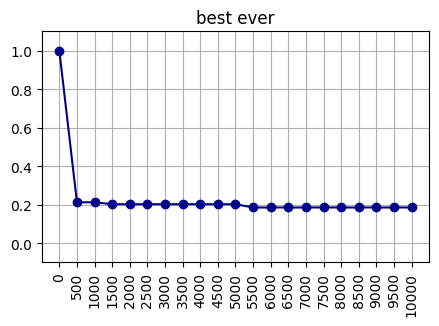

In [13]:

print ("\n=-=-=-=-=\n=-=-=-=-= FLAMBY\n=-=-=-=-=")
dimensions = 12
res,data = launch_random([0]*dimensions,ma_func=flamby,rangeValue=5)
plot_data(data,title="best ever",interval=interval,y_min=-0.1,y_max=1.1)



=-=-=-=-=
=-=-=-=-= FLAMBY
=-=-=-=-=
it = 0 , current_fit = 0.13976420679945012 , best_fit = 0.13976420679945012
it = 1000 , current_fit = 0.16306486551938515 , best_fit = 0.001894479008169303
it = 2000 , current_fit = 0.12288885604440614 , best_fit = 3.5375080851607343e-05
it = 3000 , current_fit = 0.01673002787311373 , best_fit = 3.5375080851607343e-05
it = 4000 , current_fit = 0.0413245177534568 , best_fit = 3.5375080851607343e-05
it = 5000 , current_fit = 0.15585520870414005 , best_fit = 3.5375080851607343e-05
it = 6000 , current_fit = 0.24270497419983306 , best_fit = 3.5375080851607343e-05
it = 7000 , current_fit = 0.014348281978151967 , best_fit = 3.5375080851607343e-05
it = 8000 , current_fit = 0.2065510384642013 , best_fit = 3.5375080851607343e-05
it = 9000 , current_fit = 0.0028502372337728676 , best_fit = 3.5375080851607343e-05
it = 10000 , current_fit = 0.016688428465089333 , best_fit = 3.5375080851607343e-05


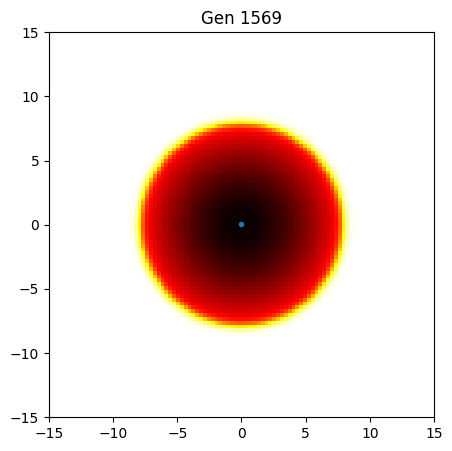

Best fit 3.5375080851607343e-05 found at iteration 1569


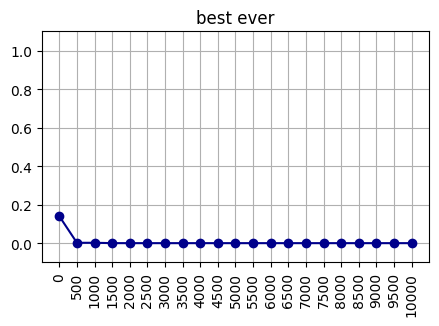

In [14]:

print ("\n=-=-=-=-=\n=-=-=-=-= FLAMBY\n=-=-=-=-=")
dimensions = 2
res,data = launch_random([0]*dimensions,ma_func=flamby,rangeValue=5)
plot_data(data,title="best ever",interval=interval,y_min=-0.1,y_max=1.1)



=-=-=-=-=
=-=-=-=-= FLAMBY
=-=-=-=-=
it = 0 , current_fit = 0.9999999999999667 , best_fit = 0.9999999999999667
it = 1000 , current_fit = 0.9999999999999986 , best_fit = 0.41133233137046554
it = 2000 , current_fit = 0.9999999999999578 , best_fit = 0.41133233137046554
it = 3000 , current_fit = 0.9999999996212218 , best_fit = 0.41133233137046554
it = 4000 , current_fit = 0.9999999999998288 , best_fit = 0.41133233137046554
it = 5000 , current_fit = 0.999999999999999 , best_fit = 0.3849413478124388
it = 6000 , current_fit = 0.9999999999957574 , best_fit = 0.3849413478124388
it = 7000 , current_fit = 0.9999999999999921 , best_fit = 0.3849413478124388
it = 8000 , current_fit = 0.9999999998299399 , best_fit = 0.3849413478124388
it = 9000 , current_fit = 0.9999999998926498 , best_fit = 0.3849413478124388
it = 10000 , current_fit = 0.9999999999999892 , best_fit = 0.3849413478124388


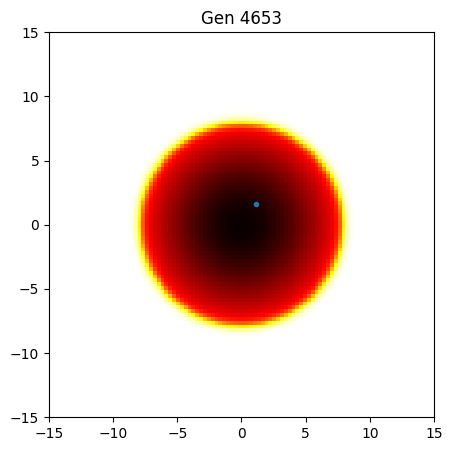

Best fit 0.3849413478124388 found at iteration 4653


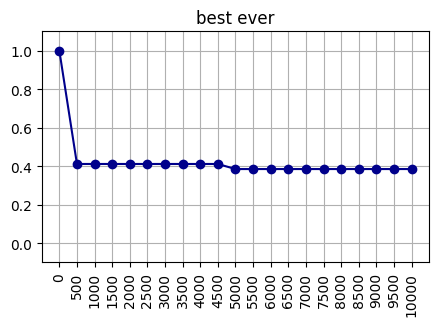

In [15]:

print ("\n=-=-=-=-=\n=-=-=-=-= FLAMBY\n=-=-=-=-=")
dimensions = 20
res,data = launch_random([0]*dimensions,ma_func=flamby,rangeValue=5)
plot_data(data,title="best ever",interval=interval,y_min=-0.1,y_max=1.1)


# Questions

1. Modifiez le code ci-dessus pour faire une recherche en 2, puis en 20 dimensions. Qu'observez vous? Pourquoi?
En 2D, on trouve facilement un best_fit proche de 0. En 20D, le best_fit reste grand (ex: 0.5) et ne descend presque pas.
À cause de la malédiction de la dimension. Le "creux" central (où la fonction est basse) est tout petit. En haute dimension, le volume de ce creux devient infime par rapport à tout l'espace, donc on a très peu de chances de tomber dedans par hasard.

---
---
---

# <font color='orange'>PARTIE B : STRATEGIES D'EVOLUTION</font>


---

# Exercice B-1: algorithme (1+1)-ES

Implementez une stratégie d'évolution (1+1)-ES avec un sigma fixe dans la cellule ci-dessous. Vous pouvez vous inspirer de la fonction de recherche aléatoire présentée précédemment pour la structure globale.

Vous testerez cet algorithme sur la fonction Flamby présenté précédemment. Vous tracerez (comme montré à la question précédente) l'évolution de la population pour chaque exécution.


=-=-=-=-=
=-=-=-=-= Flamby Function with (1+1)-ES
=-=-=-=-=
it =  1000, current_fit = 2.5610e-01, best_fit = 2.5568e-01
it =  2000, current_fit = 4.3812e-02, best_fit = 4.3514e-02
it =  3000, current_fit = 8.2860e-06, best_fit = 2.1857e-06
it =  4000, current_fit = 1.4571e-05, best_fit = 1.8411e-06
it =  5000, current_fit = 1.0606e-05, best_fit = 1.8411e-06
it =  6000, current_fit = 1.5411e-05, best_fit = 1.4867e-06
it =  7000, current_fit = 5.1371e-06, best_fit = 1.4867e-06
it =  8000, current_fit = 3.3626e-06, best_fit = 1.4867e-06
it =  9000, current_fit = 7.4583e-06, best_fit = 1.4867e-06
it = 10000, current_fit = 6.6038e-06, best_fit = 1.4867e-06


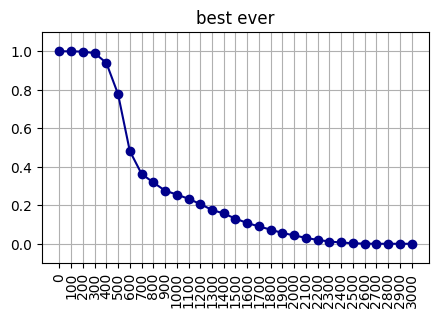

(display only the first 3000 iterations)


In [16]:
def launch_oneplusone(individual, sigma, nbeval=10001, display=True, ma_func=flamby):
    """
    (1+1)-ES with fixed sigma for minimization.
    
    Parameters:
        individual: initial solution (numpy array)
        sigma: step size (float)
        nbeval: total number of fitness evaluations
        display: whether to print progress every 10% of evaluations
        ma_func: objective function to minimize
    
    Returns:
        best_fit: best fitness found
        data: list of best fitness values after each evaluation
    """
    # Initialisation
    x = np.copy(individual)                # parent
    best_fit = ma_func(x)                   # fitness of parent
    best_x = np.copy(x)                      # best solution so far (same as parent)
    data = [best_fit]                        # record after first evaluation

    # Main loop: produce nbeval-1 offspring (since first evaluation already done)
    for i in range(1, nbeval):
        # Generate offspring by adding Gaussian noise
        x_prime = x + sigma * np.random.randn(*x.shape)
        fit_prime = ma_func(x_prime)

        # Selection: replace parent if offspring is better or equal (minimization)
        if fit_prime <= best_fit:
            x = x_prime
            best_fit = fit_prime
            best_x = np.copy(x)

        data.append(best_fit)                # record current best

        # Optional progress display
        if display and i % (nbeval // 10) == 0:
            print(f"it = {i:5d}, current_fit = {fit_prime:.4e}, best_fit = {best_fit:.4e}")

    return best_fit, data

print ("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with (1+1)-ES\n=-=-=-=-=")

dimensions = 12
rangeValue = 5
initial_solution = np.random.uniform(-rangeValue, rangeValue, dimensions)
res,data = launch_oneplusone(initial_solution,sigma=0.01,nbeval=10001,ma_func=flamby)

interval = 100
plot_data(data[:3001],title="best ever",interval=interval,y_min=-0.1,y_max=1.1)
print("(display only the first 3000 iterations)")




=-=-=-=-=
=-=-=-=-= Flamby Function with (1+1)-ES
=-=-=-=-=
it =  1000, current_fit = 8.4805e-04, best_fit = 1.8304e-04
it =  2000, current_fit = 5.6449e-04, best_fit = 1.3634e-04
it =  3000, current_fit = 6.6837e-04, best_fit = 1.3634e-04
it =  4000, current_fit = 8.1257e-04, best_fit = 1.3634e-04
it =  5000, current_fit = 1.5785e-03, best_fit = 1.2774e-04
it =  6000, current_fit = 8.7999e-04, best_fit = 1.1443e-04
it =  7000, current_fit = 7.7205e-04, best_fit = 1.1443e-04
it =  8000, current_fit = 1.6402e-03, best_fit = 1.1443e-04
it =  9000, current_fit = 7.3251e-04, best_fit = 1.1443e-04
it = 10000, current_fit = 1.8685e-03, best_fit = 1.1443e-04


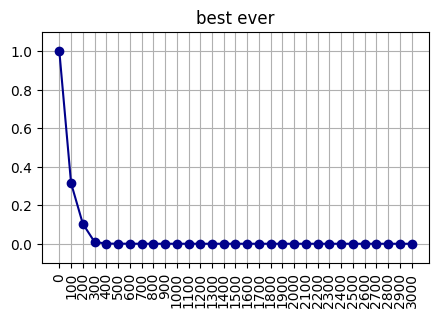

(display only the first 3000 iterations)


In [17]:
print ("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with (1+1)-ES\n=-=-=-=-=")

dimensions = 12
rangeValue = 5
initial_solution = np.random.uniform(-rangeValue, rangeValue, dimensions)
res,data = launch_oneplusone(initial_solution,sigma=0.1,nbeval=10001,ma_func=flamby)

interval = 100
plot_data(data[:3001],title="best ever",interval=interval,y_min=-0.1,y_max=1.1)
print("(display only the first 3000 iterations)")




=-=-=-=-=
=-=-=-=-= Flamby Function with (1+1)-ES
=-=-=-=-=
it =  1000, current_fit = 9.9814e-01, best_fit = 9.9813e-01
it =  2000, current_fit = 9.8773e-01, best_fit = 9.8770e-01
it =  3000, current_fit = 9.1129e-01, best_fit = 9.1102e-01
it =  4000, current_fit = 6.6332e-01, best_fit = 6.6332e-01
it =  5000, current_fit = 4.2624e-01, best_fit = 4.2599e-01
it =  6000, current_fit = 3.3659e-01, best_fit = 3.3659e-01
it =  7000, current_fit = 2.9810e-01, best_fit = 2.9807e-01
it =  8000, current_fit = 2.6891e-01, best_fit = 2.6884e-01
it =  9000, current_fit = 2.3890e-01, best_fit = 2.3890e-01
it = 10000, current_fit = 2.1185e-01, best_fit = 2.1183e-01


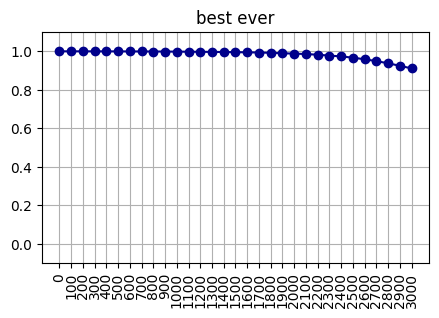

(display only the first 3000 iterations)


In [18]:
print ("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with (1+1)-ES\n=-=-=-=-=")

dimensions = 12
rangeValue = 5
initial_solution = np.random.uniform(-rangeValue, rangeValue, dimensions)
res,data = launch_oneplusone(initial_solution,sigma=0.001,nbeval=10001,ma_func=flamby)

interval = 100
plot_data(data[:3001],title="best ever",interval=interval,y_min=-0.1,y_max=1.1)
print("(display only the first 3000 iterations)")




=-=-=-=-=
=-=-=-=-= Flamby Function with (1+1)-ES in 2D, sigma=0.01, multiple runs
=-=-=-=-=
it =  1000, current_fit = 7.9531e-01, best_fit = 7.9531e-01
it =  2000, current_fit = 1.2213e-01, best_fit = 1.2213e-01
it =  3000, current_fit = 2.2142e-05, best_fit = 2.2142e-05
it =  4000, current_fit = 8.1930e-07, best_fit = 7.3392e-09
it =  5000, current_fit = 1.1904e-07, best_fit = 7.5818e-10
it =  6000, current_fit = 3.6012e-06, best_fit = 7.5818e-10
it =  7000, current_fit = 6.1176e-06, best_fit = 5.2994e-10
it =  8000, current_fit = 1.9395e-06, best_fit = 5.2994e-10
it =  9000, current_fit = 2.9878e-06, best_fit = 2.4617e-10
it = 10000, current_fit = 9.5843e-07, best_fit = 2.4617e-10
Run 1: best_fit = 2.4617e-10


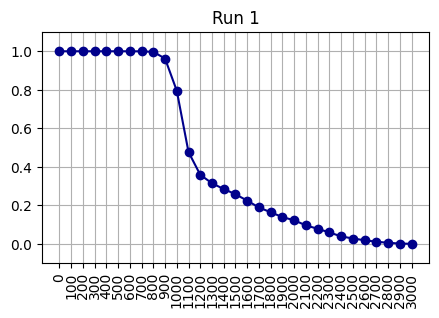

it =  1000, current_fit = 6.7287e-02, best_fit = 6.6880e-02
it =  2000, current_fit = 1.0906e-07, best_fit = 4.2085e-09
it =  3000, current_fit = 1.9562e-06, best_fit = 1.8976e-09
it =  4000, current_fit = 2.6171e-07, best_fit = 1.8976e-09
it =  5000, current_fit = 1.0844e-06, best_fit = 8.5999e-10
it =  6000, current_fit = 1.3843e-06, best_fit = 8.5999e-10
it =  7000, current_fit = 1.0408e-06, best_fit = 8.5999e-10
it =  8000, current_fit = 5.1769e-07, best_fit = 3.3948e-10
it =  9000, current_fit = 3.9937e-07, best_fit = 3.3948e-10
it = 10000, current_fit = 3.0540e-06, best_fit = 3.3948e-10
Run 2: best_fit = 3.3948e-10


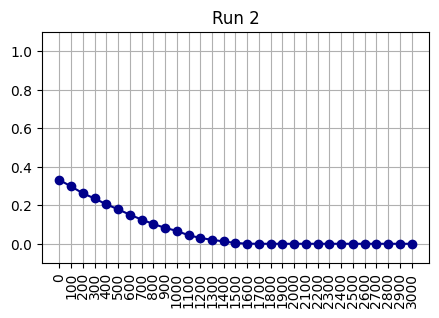

it =  1000, current_fit = 1.6756e-02, best_fit = 1.6756e-02
it =  2000, current_fit = 8.6942e-07, best_fit = 2.3517e-09
it =  3000, current_fit = 1.0827e-06, best_fit = 7.3949e-10
it =  4000, current_fit = 1.3617e-06, best_fit = 7.3949e-10
it =  5000, current_fit = 3.3146e-06, best_fit = 5.7182e-10
it =  6000, current_fit = 3.8217e-06, best_fit = 5.7182e-10
it =  7000, current_fit = 1.4706e-06, best_fit = 5.7182e-10
it =  8000, current_fit = 8.1417e-07, best_fit = 5.7182e-10
it =  9000, current_fit = 2.0064e-08, best_fit = 5.7182e-10
it = 10000, current_fit = 1.5688e-06, best_fit = 5.7182e-10
Run 3: best_fit = 5.7182e-10


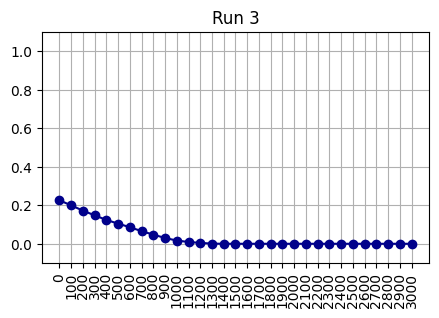

it =  1000, current_fit = 1.6585e-06, best_fit = 2.1611e-08
it =  2000, current_fit = 1.0062e-06, best_fit = 1.5221e-09
it =  3000, current_fit = 2.0267e-06, best_fit = 1.5221e-09
it =  4000, current_fit = 2.3815e-07, best_fit = 4.5091e-10
it =  5000, current_fit = 2.0885e-06, best_fit = 4.5091e-10
it =  6000, current_fit = 1.3750e-07, best_fit = 4.5091e-10
it =  7000, current_fit = 7.9998e-07, best_fit = 4.5091e-10
it =  8000, current_fit = 1.5953e-06, best_fit = 4.5091e-10
it =  9000, current_fit = 1.1625e-06, best_fit = 4.5091e-10
it = 10000, current_fit = 4.5993e-07, best_fit = 3.5497e-10
Run 4: best_fit = 3.5497e-10


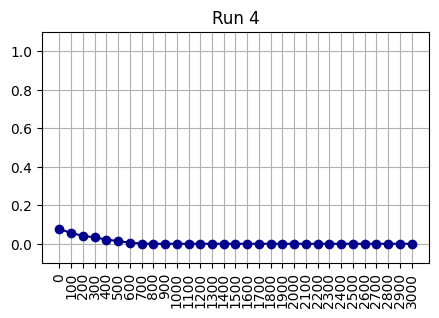

it =  1000, current_fit = 2.4383e-01, best_fit = 2.4358e-01
it =  2000, current_fit = 2.9508e-02, best_fit = 2.9508e-02
it =  3000, current_fit = 4.1627e-06, best_fit = 1.1241e-09
it =  4000, current_fit = 7.4545e-07, best_fit = 4.4197e-10
it =  5000, current_fit = 8.2538e-07, best_fit = 3.6234e-10
it =  6000, current_fit = 1.0417e-07, best_fit = 3.6234e-10
it =  7000, current_fit = 5.3841e-06, best_fit = 3.6234e-10
it =  8000, current_fit = 2.4368e-06, best_fit = 2.3360e-10
it =  9000, current_fit = 1.2947e-06, best_fit = 2.3360e-10
it = 10000, current_fit = 2.5669e-06, best_fit = 2.3360e-10
Run 5: best_fit = 2.3360e-10


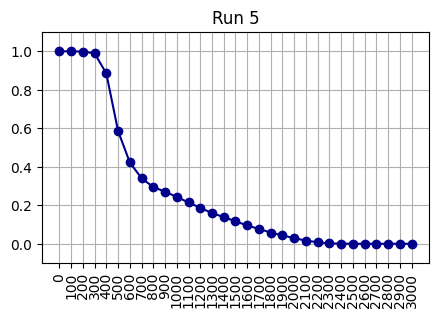

In [20]:
print("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with (1+1)-ES in 2D, sigma=0.01, multiple runs\n=-=-=-=-=")

dimensions = 2
rangeValue = 10
sigma = 0.01
n_runs = 5

for run in range(n_runs):
    initial_solution = np.random.uniform(-rangeValue, rangeValue, dimensions)
    res, data = launch_oneplusone(initial_solution, sigma=sigma, nbeval=10001, ma_func=flamby)
    print(f"Run {run+1}: best_fit = {res:.4e}")
    plot_data(data[:3001], title=f"Run {run+1}", interval=100, y_min=-0.1, y_max=1.1)


=-=-=-=-=
=-=-=-=-= Flamby Function with (1+1)-ES in 20D, sigma=0.01, multiple runs
=-=-=-=-=
it =  1000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  2000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  3000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  4000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  5000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  6000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  7000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  8000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  9000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it = 10000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
Run 1: best_fit = 1.0000e+00


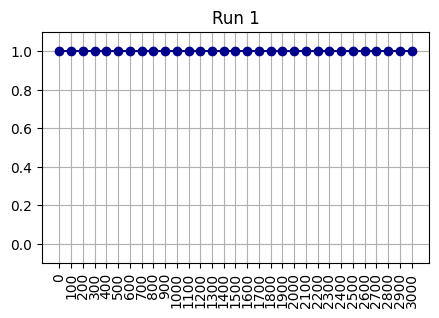

it =  1000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  2000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  3000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  4000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  5000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  6000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  7000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  8000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  9000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it = 10000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
Run 2: best_fit = 1.0000e+00


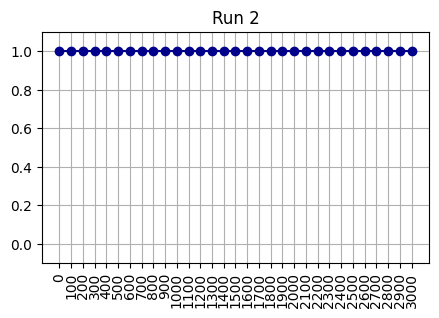

it =  1000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  2000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  3000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  4000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  5000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  6000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  7000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  8000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  9000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it = 10000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
Run 3: best_fit = 1.0000e+00


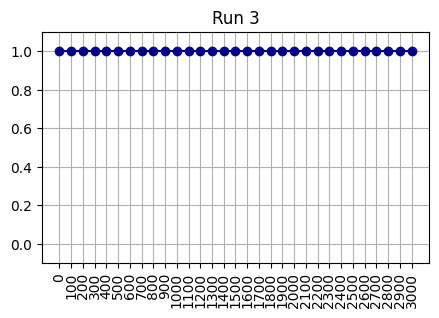

it =  1000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  2000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  3000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  4000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  5000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  6000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  7000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  8000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  9000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it = 10000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
Run 4: best_fit = 1.0000e+00


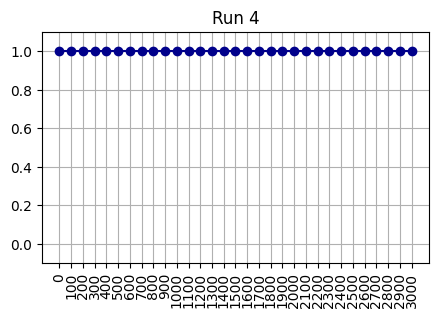

it =  1000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  2000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  3000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  4000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  5000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  6000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  7000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  8000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it =  9000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
it = 10000, current_fit = 1.0000e+00, best_fit = 1.0000e+00
Run 5: best_fit = 1.0000e+00


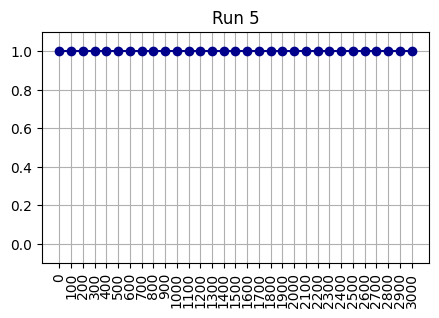

In [21]:
print("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with (1+1)-ES in 20D, sigma=0.01, multiple runs\n=-=-=-=-=")

dimensions = 20
rangeValue = 10
sigma = 0.01
n_runs = 5

for run in range(n_runs):
    initial_solution = np.random.uniform(-rangeValue, rangeValue, dimensions)
    res, data = launch_oneplusone(initial_solution, sigma=sigma, nbeval=10001, ma_func=flamby)
    print(f"Run {run+1}: best_fit = {res:.4e}")
    plot_data(data[:3001], title=f"Run {run+1}", interval=100, y_min=-0.1, y_max=1.1)

# Questions

1. lancer la recherche en changeant l'ordre de grandeur de sigma (ie. 0.1 et 0.001). Qu'observez-vous?
Avec sigma = 0.01, la convergence est rapide et la fitness finale est très faible (~10⁻⁶).
Avec sigma = 0.1, la convergence est plus lente et la fitness finale est moins bonne (~10⁻⁴).
Avec sigma = 0.001, la convergence est très lente et la fitness finale reste élevée (~0.2).
→ Un sigma trop petit fait stagner, un sigma trop grand perturbe la progression.

2. lancer plusieurs fois la recherche avec 2 dimensions et une solution initiale dont les valeurs sont tirées dans -10,+10 et sigma=0.01. Qu'observez-vous?
Chaque exécution converge vers une valeur extrêmement proche de 0 (de l'ordre de \(10^{-10}\)), l'algorithme est donc très efficace et robuste en 2D.

3. lancer plusieurs fois la recherche avec 20 dimensions et une solution initiale dont les valeurs sont tirées dans -10,+10. Qu'observez-vous? Pourquoi?
Toutes les exécutions stagnent à 1.0, sans aucune amélioration.  En haute dimension (20D), le bassin d'attraction du minimum global est extrêmement petit. Avec un sigma trop faible, l'algorithme reste piégé dans la région plate où la fonction vaut 1 et n'arrive pas à atteindre la zone centrale.

4. Pourquoi le remplacement du parent par l'enfant se fait aussi si les deux ont la même performance?
C'est pour éviter la stagnation, remplacer même à performance égale permet d'explorer de nouvelles régions de l'espace et maintient la diversité, ce qui peut aider à sortir d'un plateau.

---

# Exercice B-2: algorithme (1+1)-ES, règle des 1/5e

Nous allons maintenant implementer une stratégie d'évolution (1+1)-ES avec un sigma suivant la règle des 1/5e. Limitez la valeur de sigma entre 1e-10 et 2.

Vous testerez cette algorithme sur les mêmes fonction que précédemment. Vous tracerez l'évolution de la population pour chaque exécution. Vous étudierez l'impact du choix du point initial et du sigma.


=-=-=-=-=
=-=-=-=-= Flamby Function with (1+1)-ES 1/5th rule
=-=-=-=-=
it =  1000, current_fit = 5.9375e-13, best_fit = 5.8542e-13, sigma = 4.7684e-07
it =  2000, current_fit = 2.2204e-16, best_fit = 1.1102e-16, sigma = 3.5441e-08
it =  3000, current_fit = 3.3307e-16, best_fit = 1.1102e-16, sigma = 3.5441e-08
it =  4000, current_fit = 4.4409e-16, best_fit = 1.1102e-16, sigma = 3.5441e-08
it =  5000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 3.5441e-08
it =  6000, current_fit = 0.0000e+00, best_fit = 0.0000e+00, sigma = 3.5441e-08
it =  7000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 1.4901e-08
it =  8000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 1.4901e-08
it =  9000, current_fit = 0.0000e+00, best_fit = 0.0000e+00, sigma = 3.5441e-08
it = 10000, current_fit = 4.4409e-16, best_fit = 0.0000e+00, sigma = 3.5441e-08


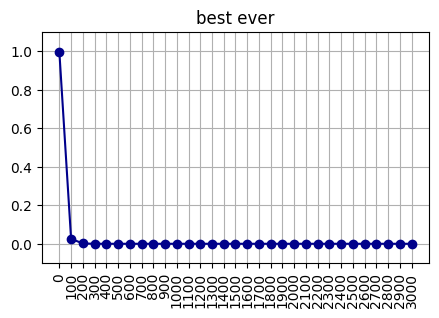

(display only the first 3000 iterations)
Terminé.


In [22]:
def launch_oneplusone_withOneFifthRule(individual, sigma_init=0.01, nbeval=10001, display=True, ma_func=flamby):
    """
    (1+1)-ES with adaptive sigma using the 1/5 rule (update at each step).
    For minimization problems.
    """
    x = np.copy(individual)
    best_fit = ma_func(x)
    best_x = np.copy(x)
    sigma = sigma_init
    data = [best_fit]

    for i in range(1, nbeval):
        # Generate offspring
        x_prime = x + sigma * np.random.randn(*x.shape)
        fit_prime = ma_func(x_prime)

        # Selection (minimization)
        if fit_prime <= best_fit:
            x = x_prime
            best_fit = fit_prime
            best_x = np.copy(x)
            # Success: increase sigma
            sigma = min(sigma * 2, 2.0)   # upper bound
        else:
            # Failure: decrease sigma
            sigma = max(sigma * (2 ** (-0.25)), 1e-10)  # lower bound

        data.append(best_fit)

        if display and i % (nbeval // 10) == 0:
            print(f"it = {i:5d}, current_fit = {fit_prime:.4e}, best_fit = {best_fit:.4e}, sigma = {sigma:.4e}")

    return best_fit, data

print ("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with (1+1)-ES 1/5th rule\n=-=-=-=-=")

dimensions = 12
rangeValue = 5
initial_solution = np.random.uniform(-rangeValue, rangeValue, dimensions)
res,data = launch_oneplusone_withOneFifthRule(initial_solution,nbeval=10001,sigma_init=0.01,ma_func=flamby)

interval = 100
plot_data(data[:3001],title="best ever",interval=interval,y_min=-0.1,y_max=1.1)
print("(display only the first 3000 iterations)")

print ("Terminé.")


=-=-=-=-=
=-=-=-=-= Flamby Function with (1+1)-ES 1/5th rule in 2D, multiple runs
=-=-=-=-=
it =  1000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 5.9605e-08
it =  2000, current_fit = 0.0000e+00, best_fit = 0.0000e+00, sigma = 3.3717e-07
it =  3000, current_fit = 7.7716e-16, best_fit = 0.0000e+00, sigma = 1.4176e-07
it =  4000, current_fit = 3.3307e-16, best_fit = 0.0000e+00, sigma = 5.9605e-08
it =  5000, current_fit = 5.5511e-16, best_fit = 0.0000e+00, sigma = 3.3717e-07
it =  6000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 5.9605e-08
it =  7000, current_fit = 7.7716e-16, best_fit = 0.0000e+00, sigma = 1.4176e-07
it =  8000, current_fit = 1.7764e-15, best_fit = 0.0000e+00, sigma = 3.3717e-07
it =  9000, current_fit = 2.2204e-16, best_fit = 0.0000e+00, sigma = 1.4176e-07
it = 10000, current_fit = 2.2204e-16, best_fit = 0.0000e+00, sigma = 1.4176e-07
Run 1: best_fit = 0.0000e+00


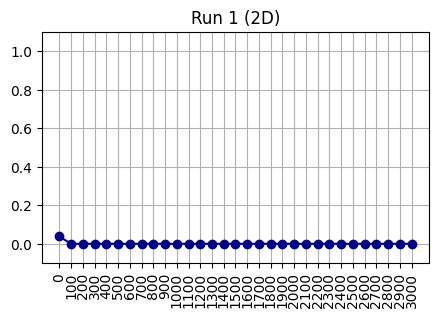

it =  1000, current_fit = 5.5511e-16, best_fit = 0.0000e+00, sigma = 2.0049e-07
it =  2000, current_fit = 3.3307e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  3000, current_fit = 2.2204e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  4000, current_fit = 1.7764e-15, best_fit = 0.0000e+00, sigma = 2.0049e-07
it =  5000, current_fit = 3.3307e-16, best_fit = 0.0000e+00, sigma = 2.0049e-07
it =  6000, current_fit = 5.5511e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  7000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 3.5441e-08
it =  8000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  9000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it = 10000, current_fit = 4.4409e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
Run 2: best_fit = 0.0000e+00


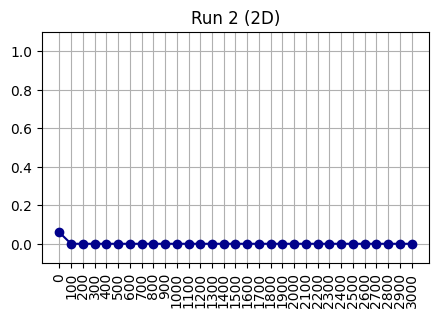

it =  1000, current_fit = 3.3307e-16, best_fit = 0.0000e+00, sigma = 1.4176e-07
it =  2000, current_fit = 0.0000e+00, best_fit = 0.0000e+00, sigma = 3.3717e-07
it =  3000, current_fit = 1.5543e-15, best_fit = 0.0000e+00, sigma = 1.4176e-07
it =  4000, current_fit = 9.9920e-16, best_fit = 0.0000e+00, sigma = 1.4176e-07
it =  5000, current_fit = 1.2212e-15, best_fit = 0.0000e+00, sigma = 3.3717e-07
it =  6000, current_fit = 8.8818e-16, best_fit = 0.0000e+00, sigma = 1.4176e-07
it =  7000, current_fit = 1.4433e-15, best_fit = 0.0000e+00, sigma = 1.4176e-07
it =  8000, current_fit = 1.1102e-15, best_fit = 0.0000e+00, sigma = 1.4176e-07
it =  9000, current_fit = 5.5511e-16, best_fit = 0.0000e+00, sigma = 1.4176e-07
it = 10000, current_fit = 3.3307e-16, best_fit = 0.0000e+00, sigma = 5.9605e-08
Run 3: best_fit = 0.0000e+00


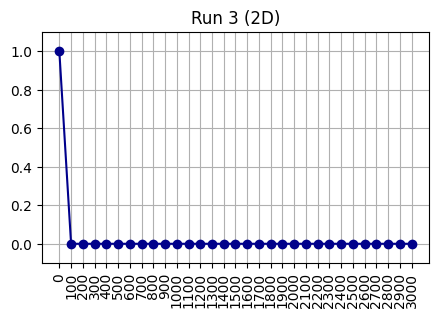

it =  1000, current_fit = 2.2204e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  2000, current_fit = 0.0000e+00, best_fit = 0.0000e+00, sigma = 2.0049e-07
it =  3000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  4000, current_fit = 4.4409e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  5000, current_fit = 4.4409e-16, best_fit = 0.0000e+00, sigma = 2.0049e-07
it =  6000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  7000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  8000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  9000, current_fit = 2.2204e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it = 10000, current_fit = 2.2204e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
Run 4: best_fit = 0.0000e+00


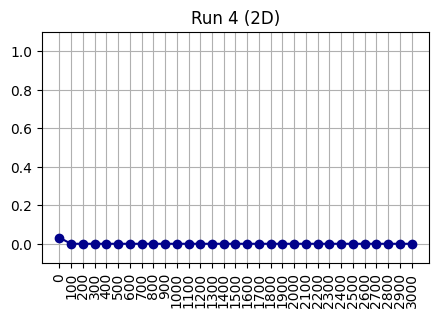

it =  1000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  2000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  3000, current_fit = 0.0000e+00, best_fit = 0.0000e+00, sigma = 2.0049e-07
it =  4000, current_fit = 3.3307e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  5000, current_fit = 5.5511e-16, best_fit = 0.0000e+00, sigma = 2.0049e-07
it =  6000, current_fit = 0.0000e+00, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  7000, current_fit = 1.1102e-16, best_fit = 0.0000e+00, sigma = 2.0049e-07
it =  8000, current_fit = 2.2204e-16, best_fit = 0.0000e+00, sigma = 8.4294e-08
it =  9000, current_fit = 0.0000e+00, best_fit = 0.0000e+00, sigma = 2.0049e-07
it = 10000, current_fit = 6.6613e-16, best_fit = 0.0000e+00, sigma = 2.0049e-07
Run 5: best_fit = 0.0000e+00


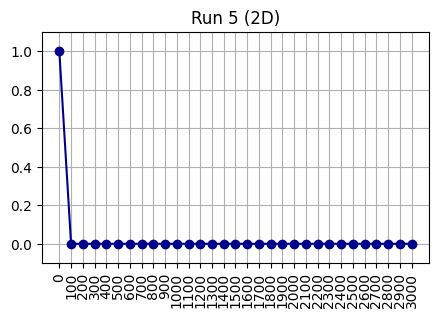

In [23]:
# Question 1: 2 dimensions, multiple runs, compare with previous (fixed sigma) results
print("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with (1+1)-ES 1/5th rule in 2D, multiple runs\n=-=-=-=-=")

dimensions = 2
rangeValue = 10
sigma_init = 0.01
n_runs = 5

for run in range(n_runs):
    initial_solution = np.random.uniform(-rangeValue, rangeValue, dimensions)
    res, data = launch_oneplusone_withOneFifthRule(initial_solution, nbeval=10001, sigma_init=sigma_init, ma_func=flamby)
    print(f"Run {run+1}: best_fit = {res:.4e}")
    plot_data(data[:3001], title=f"Run {run+1} (2D)", interval=100, y_min=-0.1, y_max=1.1)


=-=-=-=-=
=-=-=-=-= Flamby Function with (1+1)-ES 1/5th rule in 20D, multiple runs
=-=-=-=-=
it =  1000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  2000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  3000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  4000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  5000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  6000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  7000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  8000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  9000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it = 10000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
Run 1: best_fit = 1.0000e+00


/var/folders/x0/9jmwqqtj7s13pdfprxbhp6r00000gn/T/ipykernel_9213/542463808.py:43: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-k * x))


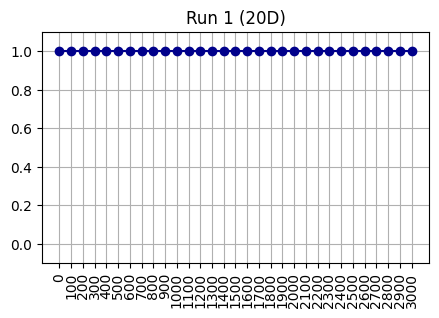

it =  1000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  2000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  3000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  4000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  5000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  6000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  7000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  8000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  9000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it = 10000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
Run 2: best_fit = 1.0000e+00


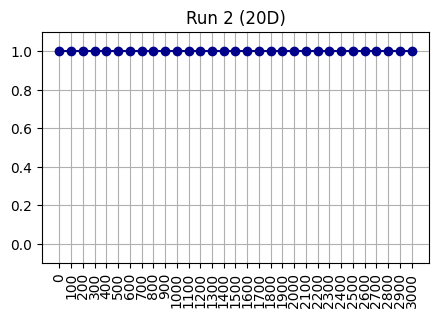

it =  1000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  2000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  3000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  4000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  5000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  6000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  7000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  8000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  9000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it = 10000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
Run 3: best_fit = 1.0000e+00


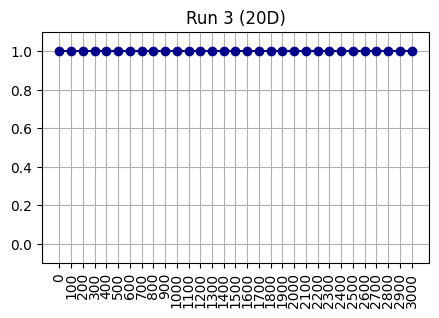

it =  1000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  2000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  3000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  4000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  5000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  6000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  7000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  8000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  9000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it = 10000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
Run 4: best_fit = 1.0000e+00


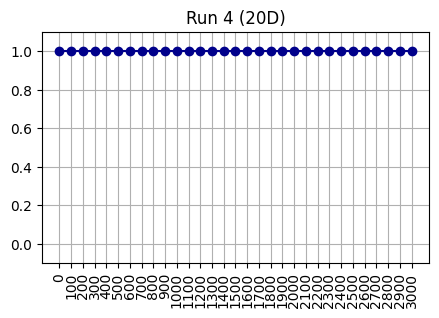

it =  1000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  2000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  3000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  4000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  5000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  6000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  7000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  8000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it =  9000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
it = 10000, current_fit = 1.0000e+00, best_fit = 1.0000e+00, sigma = 2.0000e+00
Run 5: best_fit = 1.0000e+00


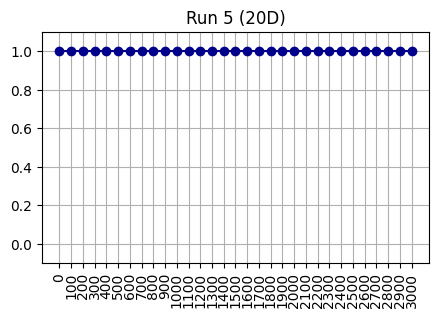

In [24]:
# Question 2: 20 dimensions, multiple runs
print("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with (1+1)-ES 1/5th rule in 20D, multiple runs\n=-=-=-=-=")

dimensions = 20
rangeValue = 10
sigma_init = 0.01
n_runs = 5

for run in range(n_runs):
    initial_solution = np.random.uniform(-rangeValue, rangeValue, dimensions)
    res, data = launch_oneplusone_withOneFifthRule(initial_solution, nbeval=10001, sigma_init=sigma_init, ma_func=flamby)
    print(f"Run {run+1}: best_fit = {res:.4e}")
    plot_data(data[:3001], title=f"Run {run+1} (20D)", interval=100, y_min=-0.1, y_max=1.1)

# Questions

1. lancer plusieurs fois la recherche avec 2 dimensions et une solution initiale dont les valeurs sont tirées dans -10,+10. Comparez avec les résultats obtenus précédemment. Qu'observez-vous?
En 2D, on atteint toujours 0 comme avant, mais le sigma s'adapte automatiquement.


2. lancer plusieurs fois la recherche avec 20 dimensions et une solution initiale dont les valeurs sont tirées dans -10,+10. Qu'observez-vous?
En 20D, l'algorithme reste bloqué à 1.0, incapable de progresser, même avec adaptation du sigma.


---

# Exercice B-3: algorithme CMA-ES

Nous allons maintenant utiliser CMA-ES. La version standard est celle proposée dans la bibliothèque pycma (https://github.com/CMA-ES/pycma). Vous testerez cette bibliothèque sur les mêmes fonctions que précédemment.



=-=-=-=-=
=-=-=-=-= Flamby Function with CMA-ES
=-=-=-=-=
(8_w,17)-aCMA-ES (mu_w=5.1,w_1=31%) in dimension 100 (seed=227292, Thu Feb 26 17:01:42 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     17 1.000000000000000e+00 1.0e+00 4.80e-01  5e-01  5e-01 0:00.0
    2     34 1.000000000000000e+00 1.0e+00 4.64e-01  5e-01  5e-01 0:00.0
termination on {'tolflatfitness': 1}
final/bestever f-value = 1.000000e+00 1.000000e+00 after 34/1 evaluations
incumbent solution: [ 0.88418838 -0.32279813 -0.07020303 -0.28022287  1.3280017   0.73546746
 -2.00451366 -2.30455142 ...]
std deviations: [0.4640456  0.46448555 0.46437186 0.46451874 0.46441699 0.46424183
 0.46431575 0.46455875 ...]


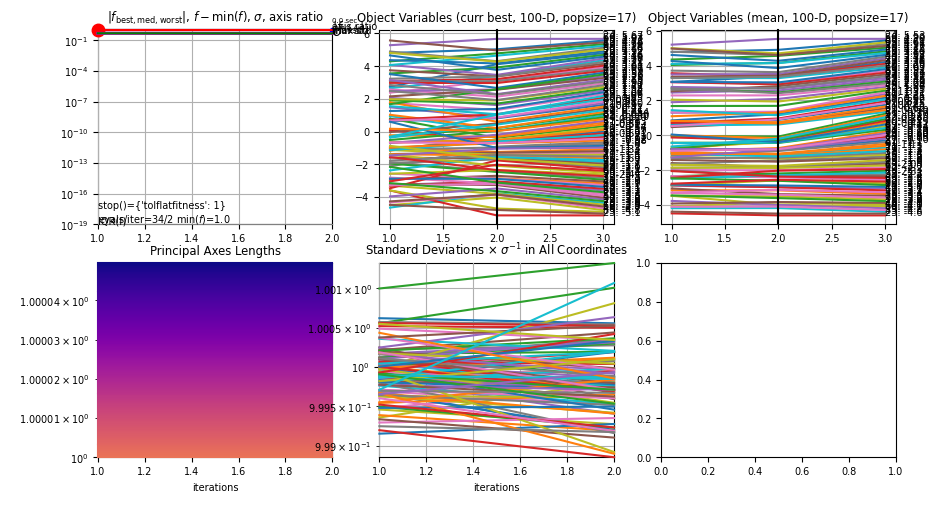

CMA-ES terminé. Meilleure fitness : 1.0000e+00
Terminé.


In [42]:
# python -m pip install cma -- déjà fait avant.
import cma

def launch_cmaes(dim=12, display=True, ma_func=flamby, maxfevals=10001):
    x0 = np.random.uniform(-5, 5, dim)
    sigma0 = 0.5
    opts = {
        'maxfevals': maxfevals,
        'verbose': -1 if not display else 1,
        'verb_disp': 100,
        'tolfun': 0,          
        'tolx': 0,             
        'tolconditioncov': 0,  
        }
    es = cma.CMAEvolutionStrategy(x0, sigma0, opts)
    es.optimize(lambda x: ma_func(np.array(x)))
    es.plot()
    best_fitness = es.result.fbest
    if display:
        print(f"CMA-ES terminé. Meilleure fitness : {best_fitness:.4e}")
    return best_fitness

print ("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with CMA-ES\n=-=-=-=-=")

dimensions = 100
besteverFitness = launch_cmaes(dim=dimensions,display=True,ma_func=flamby)

print ("Terminé.")


=-=-=-=-=
=-=-=-=-= Flamby Function with CMA-ES
=-=-=-=-=
(5_w,11)-aCMA-ES (mu_w=3.4,w_1=42%) in dimension 12 (seed=233856, Thu Feb 26 17:01:56 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     11 9.944998151201826e-01 1.0e+00 4.85e-01  5e-01  5e-01 0:00.0
    2     22 9.765602631380754e-01 1.2e+00 5.01e-01  5e-01  5e-01 0:00.0
    3     33 7.887593206243151e-01 1.3e+00 5.16e-01  5e-01  5e-01 0:00.0
  100   1100 1.402436677122587e-06 1.7e+00 7.00e-03  3e-03  4e-03 0:00.0
  200   2200 5.264677582772492e-13 2.0e+00 8.47e-06  2e-06  3e-06 0:00.1
  234   2574 5.218048215738236e-15 1.9e+00 1.26e-06  2e-07  3e-07 0:00.1
termination on {'tolfunhist': 1e-12}
final/bestever f-value = 5.218048e-15 3.330669e-15 after 2574/2544 evaluations
incumbent solution: [ 1.65132487e-07 -1.22709060e-07 -6.20231824e-08  1.70765715e-07
 -1.66909722e-08  8.54936843e-08 -1.87555001e-07  3.06852525e-07 ...]
std deviations: [2.62599690e-07 2.61367989e-07 2.92080230e-07 2.9761

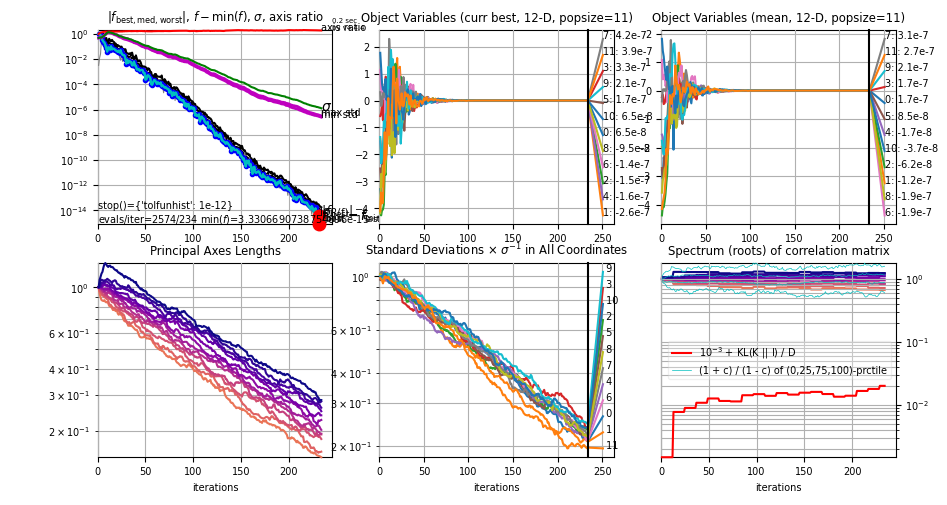

CMA-ES terminé. Meilleure fitness : 3.3307e-15
Terminé.


In [43]:
print ("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with CMA-ES\n=-=-=-=-=")

dimensions = 12
besteverFitness = launch_cmaes(dim=dimensions,display=True,ma_func=flamby)

print ("Terminé.")


=-=-=-=-=
=-=-=-=-= Flamby Function with CMA-ES
=-=-=-=-=
(5_w,11)-aCMA-ES (mu_w=3.4,w_1=42%) in dimension 12 (seed=216369, Thu Feb 26 17:02:04 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     11 2.071182299329352e+02 1.0e+00 4.59e-01  4e-01  5e-01 0:00.0
    2     22 2.096723046151559e+02 1.2e+00 4.72e-01  4e-01  5e-01 0:00.0
    3     33 2.128451416677988e+02 1.3e+00 4.77e-01  4e-01  5e-01 0:00.0
  100   1100 4.116483048575986e+01 2.7e+00 6.13e-02  3e-02  6e-02 0:00.0
  200   2200 3.581843193024048e+01 2.1e+00 8.18e-05  2e-05  3e-05 0:00.1
  300   3300 3.581843020048258e+01 2.0e+00 8.48e-08  1e-08  2e-08 0:00.1
  342   3762 3.581843020048157e+01 2.3e+00 1.09e-08  1e-09  2e-09 0:00.1
termination on {'tolfunhist': 1e-12}
final/bestever f-value = 3.581843e+01 3.581843e+01 after 3762/3648 evaluations
incumbent solution: [ 9.94958636e-01 -9.94958639e-01  8.51152743e-10  9.94958637e-01
 -2.98485570e+00  2.98485570e+00 -9.94958639e-01 -2.98485570e+00 

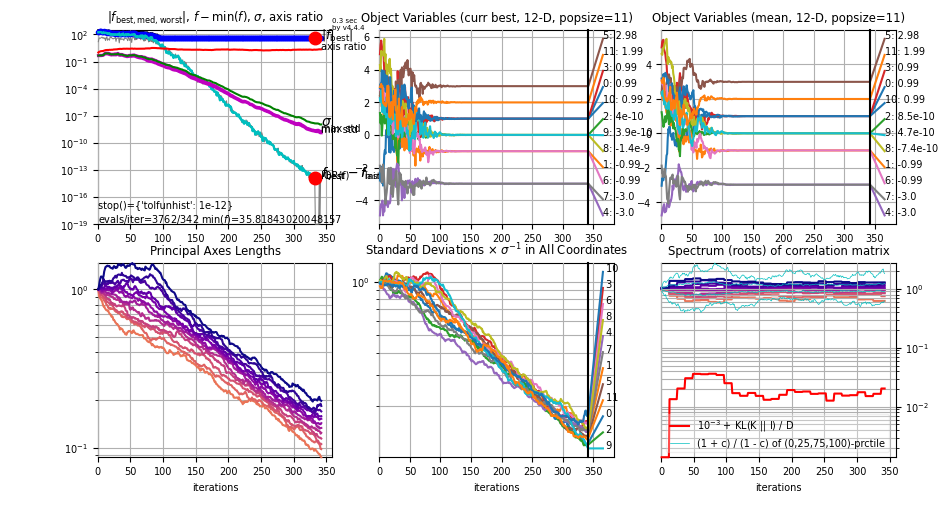

CMA-ES terminé. Meilleure fitness : 3.5818e+01
Terminé.


In [44]:
print ("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with CMA-ES\n=-=-=-=-=")

dimensions = 12
besteverFitness = launch_cmaes(dim=dimensions,display=True,ma_func=rastrigin)

print ("Terminé.")


=-=-=-=-=
=-=-=-=-= Flamby Function with CMA-ES
=-=-=-=-=
(5_w,11)-aCMA-ES (mu_w=3.4,w_1=42%) in dimension 12 (seed=210215, Thu Feb 26 17:02:05 2026)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     11 9.823354105650303e+00 1.0e+00 4.96e-01  5e-01  5e-01 0:00.0
    2     22 9.935135051148272e+00 1.2e+00 5.11e-01  5e-01  6e-01 0:00.0
    3     33 9.444889193231093e+00 1.3e+00 5.50e-01  5e-01  6e-01 0:00.0
  100   1100 2.077121837121609e-02 1.8e+00 8.99e-03  5e-03  6e-03 0:00.0
  200   2200 7.571613037482550e-05 1.9e+00 6.96e-05  2e-05  2e-05 0:00.1
  300   3300 3.205974818953905e-08 1.8e+00 7.09e-08  1e-08  1e-08 0:00.1
  400   4400 7.694467285546125e-11 1.8e+00 2.23e-10  2e-11  2e-11 0:00.1
  424   4664 1.499955715189571e-11 1.8e+00 5.58e-11  3e-12  4e-12 0:00.1
termination on {'tolxstagnation': [1e-09, 20, 0.1]}
final/bestever f-value = 1.499956e-11 1.356781e-11 after 4664/4643 evaluations
incumbent solution: [-8.64461990e-13 -4.47871837e-12 -2.464829

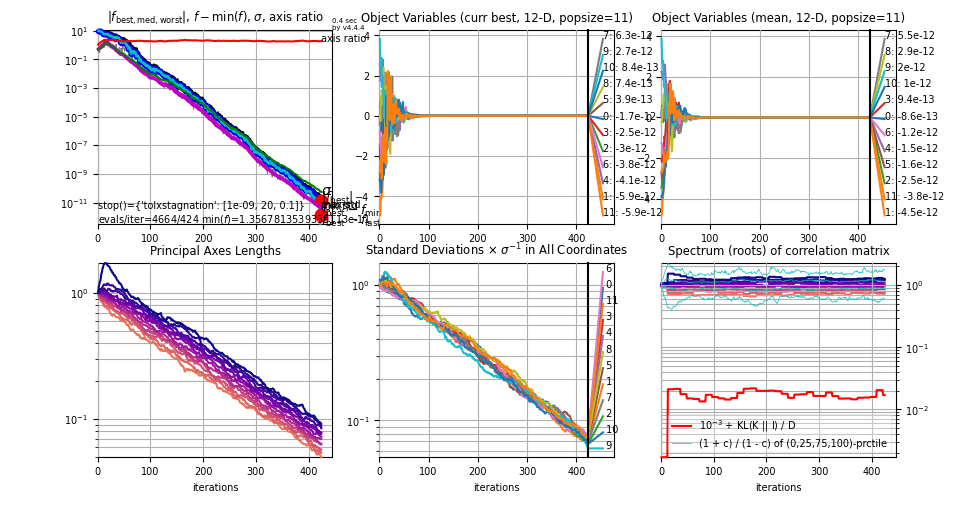

CMA-ES terminé. Meilleure fitness : 1.3568e-11
Terminé.


In [45]:
print ("\n=-=-=-=-=\n=-=-=-=-= Flamby Function with CMA-ES\n=-=-=-=-=")

dimensions = 12
besteverFitness = launch_cmaes(dim=dimensions,display=True,ma_func=ackley)

print ("Terminé.")

# Questions

1. lancez la recherche avec CMA-ES en 12 dimensions. Comparez avec les algos précédents. Qu'observez-vous?
En 12D, CMA-ES trouve une valeur de ~5e-15 pour Flamby, bien meilleure que les algorithmes précédents (10⁻⁶). Il est bien plus précis.

2. lancez la recherche avec CMA-ES en 100 dimensions. Comparez avec les algos précédents. Qu'observez-vous?
En 100D, CMA-ES échoue et reste à 1.0 (arrêt après 2 itérations). La malédiction de la dimension est trop forte.

3. lancez la recherche avec CMA-ES en 12 dimensions sur d'autres fonctions plus complexes (Rastrigin et Ackley). Comparez avec les algos précédents. Qu'observez-vous?
Sur Rastrigin (12D), il trouve ~35.8 (minimum global 0). Il est piégé dans un minimum local, mais performe mieux que les recherches aléatoires. Sur Ackley (12D), il trouve ~1.4e-11, excellente précision proche du minimum global.

4. Commentez les graphes générés par CMAES
Les graphes montrent la décroissance rapide de la fitness, l'adaptation du pas (sigma) et du conditionnement (axis ratio). En 100D, pas de graphe car trop peu d'itérations.

5. Comment forcer cma-es à chercher des valeurs de paramètres dans un intervale limité à [-5,+5]? Aide: lisez la section "Practical Hints" de https://cma-es.github.io/cmaes_sourcecode_page.html
Pour limiter à [-5, 5], il faut créer une **fonction "wrapper"** qui transforme les variables sans contrainte `x` (ex. de [0,10]) en variables contraintes `y` dans [-5, 5], par exemple avec `y = -5 + 10 * (x / 10)` (transformation linéaire).



---
---
---

# <font color='orange'>PARTIE C : PERFORMANCE</font>

---

# Exercice C-1: stabilité des résultats

Tous les algorithmes vus jusqu'ici utilisent des opérateurs stochastiques. Même en partant des mêmes conditions initiales (solution initiale et paramètres identitiques), deux éxecutions du même algorithme peut donner des résultats différents.

Le code ci-dessous permet d'exécuter 10 fois de suite une recherche au hasard pour le problème de la fonction Flamby pour respectivement 4, 16 puis 32 dimensions (i.e. 3x10 exécutions en tout).

Exécutez la cellule et observez les résultats.

Random search on Flamby function with 4 dimensions
Best fit 0.0009366933414595158 found at iteration 1672
Best fit 0.005443010023689521 found at iteration 898
Best fit 0.00452722140934092 found at iteration 8291
Best fit 0.006815076711543466 found at iteration 2738
Best fit 0.00177685021081464 found at iteration 7957
Best fit 0.003347971613781864 found at iteration 5920
Best fit 0.0035086530820184203 found at iteration 9050
Best fit 0.003004798406399889 found at iteration 3717
Best fit 0.0012859340583932788 found at iteration 4289
Best fit 0.0018004062072614069 found at iteration 2683
Random search on Flamby function with 16 dimensions
Best fit 0.2437896586040117 found at iteration 5975
Best fit 0.27091330271129366 found at iteration 4872
Best fit 0.22500641365325968 found at iteration 9688
Best fit 0.2688734367028762 found at iteration 825
Best fit 0.25092262014335076 found at iteration 656
Best fit 0.24573920472033328 found at iteration 3623
Best fit 0.23496968550578967 found at iter

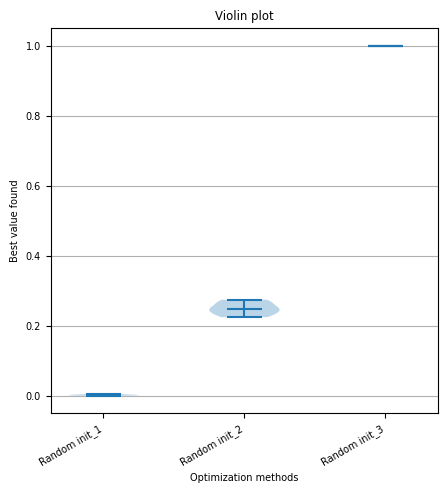

Terminé.


In [46]:
# fourni a titre d'exemple, ne pas modifier -- répondre dans la cellule suivante.

resRandom_1 = []
resRandom_2 = []
resRandom_3 = []

allResults = {}

centerInit_1 = [0]*4
centerInit_2 = [0]*16
centerInit_3 = [0]*32

evaluationBudget = 10001
evalFunc = flamby

print("Random search on Flamby function with",len(centerInit_1),"dimensions")
for i in range(10):
    resRandom_1.append ( launch_random(centerInit_1,nbeval=evaluationBudget,display=False,ma_func=evalFunc,rangeValue=5)[0] )
allResults["Random init_1"] = resRandom_1

print("Random search on Flamby function with",len(centerInit_2),"dimensions")
for i in range(10):
    resRandom_2.append ( launch_random(centerInit_2,nbeval=evaluationBudget,display=False,ma_func=evalFunc,rangeValue=5)[0] )
allResults["Random init_2"] = resRandom_2

print("Random search on Flamby function with",len(centerInit_3),"dimensions")
for i in range(10):
    resRandom_3.append ( launch_random(centerInit_3,nbeval=evaluationBudget,display=False,ma_func=evalFunc,rangeValue=5)[0] )
allResults["Random init_3"] = resRandom_3

plot_violin( allResults )

print ("Terminé.")


# Questions

1. Qu'observez vous, en particulier pour le second setup? Pourquoi?
Pour le second setup (16D), on observe que les valeurs optimales sont autour de 0.25, bien plus élevées qu'en 4D. Cela s'explique par la malédiction de la dimension : le volume du bassin d'attraction du minimum global diminue exponentiellement, rendant plus difficile de tomber dedans par hasard.

2. Pourquoi est-ce différent pour les deux autres setups?
Pour les autres setups, en 4D, le bassin est encore suffisamment grand, donc on trouve des valeurs proches de 0. En 32D, le bassin est devenu tellement minuscule que les échantillons aléatoires ne l'atteignent quasiment jamais, et on reste à 1.0 (région plate).


---

# Exercice C-2: comparaison des algorithmes

On souhaite maintenant comparer les différents algorithmes jusqu'ici (random search, (1+1)-ES, (1+1)-ES 1/5th rule, CMAES) et deux algorithmes plus classiques (Nelder Mead et Powell). Etudiez et exécutez le code ci-dessous.

Random search on Flamby function with 16 dimensions
Best fit 0.2846291366713143 found at iteration 2562
Best fit 0.23280543806743126 found at iteration 7140
Best fit 0.23878448475712177 found at iteration 1073
Best fit 0.23480182978430808 found at iteration 324
Best fit 0.27460786828066164 found at iteration 4390
Best fit 0.27513580530438686 found at iteration 9717
Best fit 0.16679669084084925 found at iteration 4893
Best fit 0.26666427252696157 found at iteration 8429
Best fit 0.2346166769603526 found at iteration 4717
Best fit 0.25126450213963303 found at iteration 7286
Powell on Flamby function with 16 dimensions
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
Neldermead on Flamby function with 16 dimensions
0.06421376983701299
0.11333598389852906


/var/folders/x0/9jmwqqtj7s13pdfprxbhp6r00000gn/T/ipykernel_9213/3161801774.py:2: OptimizeWarning: Unknown solver options: xtol
  nelder = minimize(ma_func, center, method='nelder-mead',options={'xtol': 1e-8, 'disp': display})


0.00017852827474484911
0.0004983781749124949
5.431190970206501e-05
0.022867037923057332
0.009459190488578018
0.0555799075852309
0.00041050625478333824
0.21245553020018992


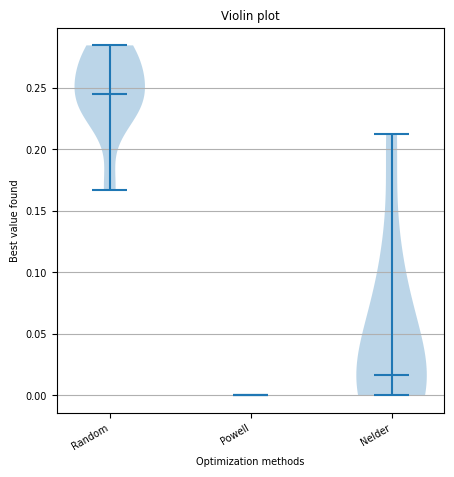

Terminé.


In [47]:
def launch_nelder(center, nbeval=10001, display=False, ma_func=sphere):
    nelder = minimize(ma_func, center, method='nelder-mead',options={'xtol': 1e-8, 'disp': display})
    print (nelder.fun)
    return nelder.fun

def launch_powell(center, nbeval=10001, display=False, ma_func=sphere):
    powell = minimize(ma_func, center, method='powell',options={'xtol': 1e-8, 'disp': display})
    print (powell.fun)
    return powell.fun

resRandom = []
resPowell = []
resNelder = []

allResults = {}

centerInit = [0]*16
rangeValue = 5

evaluationBudget = 10001
evalFunc = flamby

print("Random search on Flamby function with",len(centerInit),"dimensions")
for i in range(10):
  #centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit)) # useless for random search
  resRandom.append ( launch_random(centerInit,nbeval=evaluationBudget,display=False,ma_func=evalFunc,rangeValue=rangeValue)[0] )
allResults["Random"] = resRandom

print("Powell on Flamby function with",len(centerInit),"dimensions")
for i in range(10):
  centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit))
  resPowell.append( launch_powell(centerInit, nbeval=evaluationBudget, display=False, ma_func=evalFunc) )
allResults["Powell"] = resPowell

print("Neldermead on Flamby function with",len(centerInit),"dimensions")
for i in range(10):
  centerInit = np.random.randint(-rangeValue,rangeValue, len(centerInit))
  resNelder.append ( launch_nelder(centerInit, nbeval=evaluationBudget, display=False, ma_func=evalFunc) )
allResults["Nelder"] = resNelder

plot_violin( allResults )

print ("Terminé.")


# Questions

Remarque: les algorithmes produisant des résultats très différents, n'hésitez pas à supprimer l'affichage des plus mauvais pour pouvoir distinguer les meilleurs.

1. ajoutez les algorithmes vus précédemment. Comparez sur la fonction Flamby en 16 dimensions. Qu'observez-vous?

2. comparez sur la fonction Rastrigin en 100 dimensions. Qu'observez-vous?

3. dans la question (2), modifiez les paramètres de CMAES concernant les conditions d'arrêt de l'algorithme pour obtenir une meilleure performance (cf. docs pour les paramètres). Etudiez en particulier la tolérance pour l'arrêt prématuré de la recherche et la possibilité de faire un Restart (cf. docs).


---
---
---

# <font color='orange'>PARTIE D : BONUS</font>

Exercice optionnel à faire en autonomie.

Implémentez l'algorithme CEM (Cross-Entropy Method) vu en cours. Comparez avec les algorithmes précédents, en particulier CMA-ES.

In [48]:
def launch_cem(dim=12, n_samples=100, elite_frac=0.1, max_iters=100, ma_func=flamby):
    """
    Cross-Entropy Method for continuous optimization.
    Parameters:
        dim: problem dimension
        n_samples: number of samples per iteration
        elite_frac: fraction of top samples to use for updating
        max_iters: maximum number of iterations
        ma_func: objective function (minimization)
    Returns:
        best_solution: best solution found
        best_fitness: corresponding fitness
    """
    # Initialize distribution parameters (e.g., mean and std)
    mu = np.random.uniform(-5, 5, dim)
    sigma = np.ones(dim) * 2.0  # initial standard deviation

    best_fitness = float('inf')
    best_solution = mu.copy()

    for it in range(max_iters):
        # Sample from current Gaussian
        samples = np.random.normal(mu, sigma, size=(n_samples, dim))
        # Evaluate
        fitness = np.array([ma_func(s) for s in samples])

        # Select elite samples (lowest fitness for minimization)
        n_elite = int(elite_frac * n_samples)
        elite_indices = np.argsort(fitness)[:n_elite]
        elite_samples = samples[elite_indices]

        # Update distribution parameters
        mu_new = np.mean(elite_samples, axis=0)
        sigma_new = np.std(elite_samples, axis=0, ddof=1)  # sample std

        # Smooth update to avoid oscillations (optional)
        alpha = 0.7  # learning rate
        mu = alpha * mu_new + (1 - alpha) * mu
        sigma = alpha * sigma_new + (1 - alpha) * sigma

        # Track best ever
        current_best = fitness.min()
        if current_best < best_fitness:
            best_fitness = current_best
            best_solution = samples[elite_indices[0]].copy()

        # Optional: display progress
        if it % 10 == 0:
            print(f"Iter {it}, best fitness: {best_fitness:.4e}")

    return best_solution, best_fitness

*Fin du sujet.*
